In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [5]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541909
Number of columns: 8


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
df = df.dropna(subset=['CustomerID'])

In [10]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [11]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [12]:
print("Rows after removing cancelled transactions:", len(df))

Rows after removing cancelled transactions: 397924


In [13]:
df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
]

In [14]:
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,397884.000000,397884.000000
mean,12.988238,3.116488
std,179.331775,22.097877
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


In [16]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [17]:
latest_date = df['InvoiceDate'].max()

print("Latest transaction date:")
print(latest_date)

Latest transaction date:
2011-12-09 12:50:00


In [19]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

frequency.columns = ['CustomerID', 'Frequency']

frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [21]:
recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (
    latest_date - recency['InvoiceDate']
).dt.days

recency = recency[['CustomerID', 'Recency']]

recency.head()

,CustomerID,Recency
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [22]:
monetary = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()

monetary.columns = ['CustomerID', 'Monetary']

monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [23]:
rfm = recency.merge(
    frequency,
    on='CustomerID'
)

rfm = rfm.merge(
    monetary,
    on='CustomerID'
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [24]:
print("Number of customers:", len(rfm))

rfm.describe()

Number of customers: 4338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,91.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,0.000000,1.000000,3.750000
25%,13813.250000,17.000000,1.000000,307.415000
50%,15299.500000,50.000000,2.000000,674.485000
75%,16778.750000,141.000000,5.000000,1661.740000
max,18287.000000,373.000000,209.000000,280206.020000


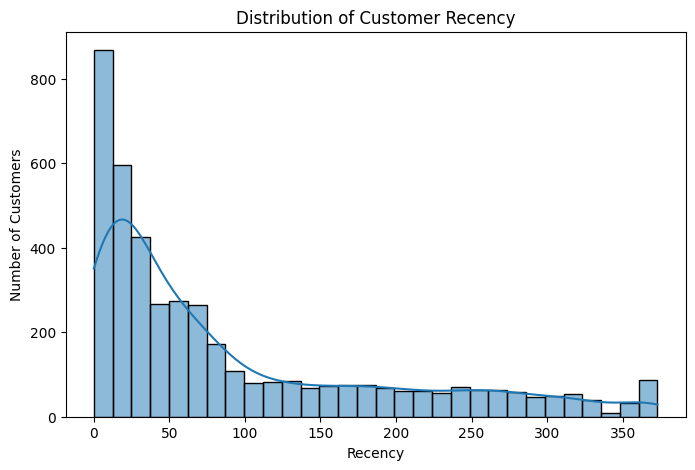

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm['Recency'],
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Recency')
plt.xlabel('Recency')
plt.ylabel('Number of Customers')

plt.show()

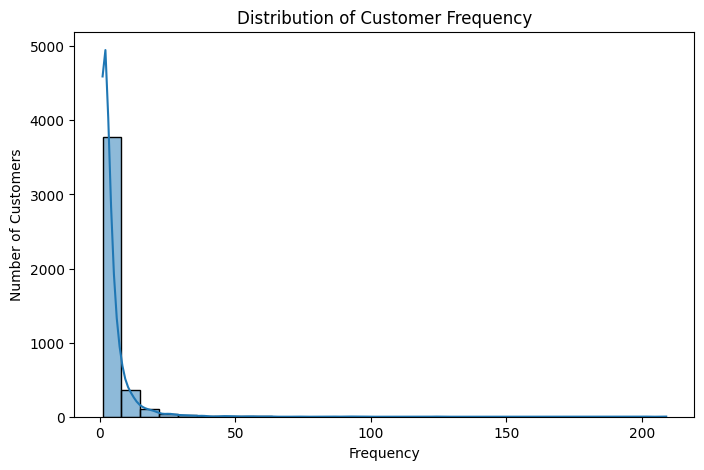

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm['Frequency'],
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Frequency')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')

plt.show()

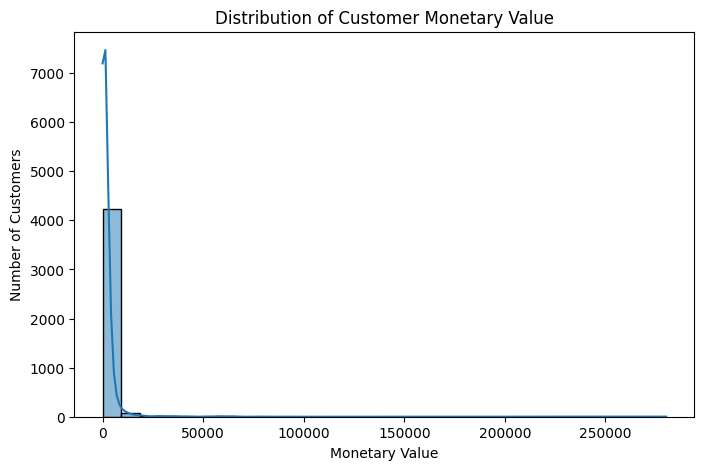

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm['Monetary'],
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Monetary Value')
plt.ylabel('Number of Customers')

plt.show()

In [28]:
features = rfm[
    ['Recency', 'Frequency', 'Monetary']
]

In [29]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

In [30]:
print(rfm_scaled[:5])


[[ 2.33457414 -0.4250965   8.35866818]
 [-0.90534032  0.3544168   0.25096626]
 [-0.17535959 -0.03533985 -0.02859601]
 [-0.73534481 -0.4250965  -0.0330118 ]
 [ 2.17457836 -0.4250965  -0.19134727]]


In [31]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

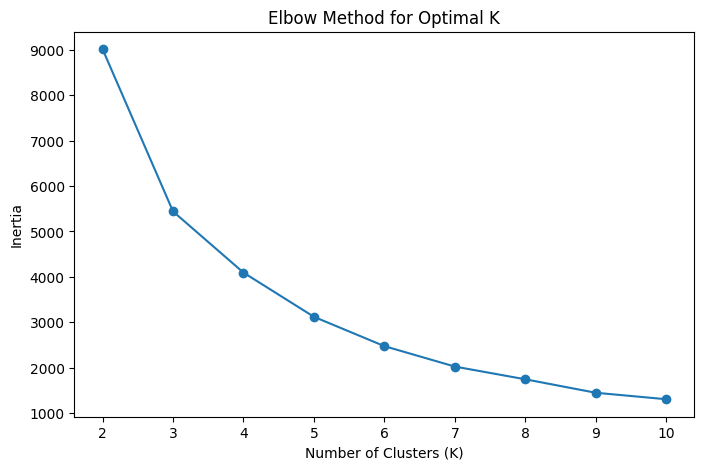

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

In [33]:
n_clusters = 3

In [34]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [35]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,325,1,77183.60,3
1,12347.0,1,7,4310.00,0
2,12348.0,74,4,1797.24,0
3,12349.0,18,1,1757.55,0
4,12350.0,309,1,334.40,1


In [36]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3054
1,1067
2,13
3,204


In [37]:
cluster_summary = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.702685,3.682711,1359.049284
1,247.075914,1.552015,480.617480
2,6.384615,82.538462,127338.313846
3,14.500000,22.333333,12709.090490


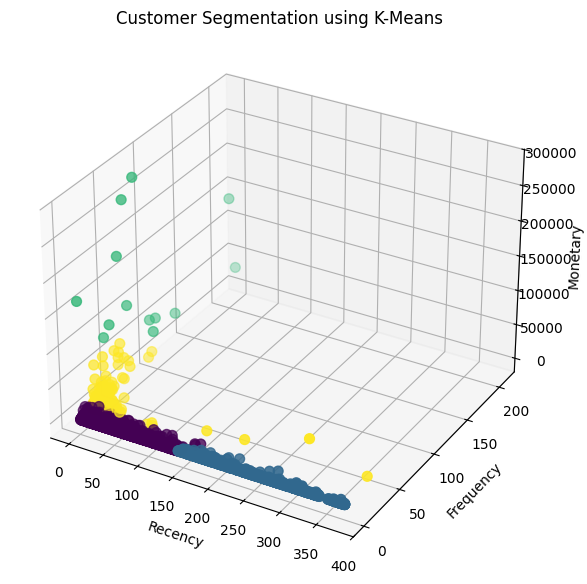

In [38]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    s=50
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('Customer Segmentation using K-Means')

plt.show()

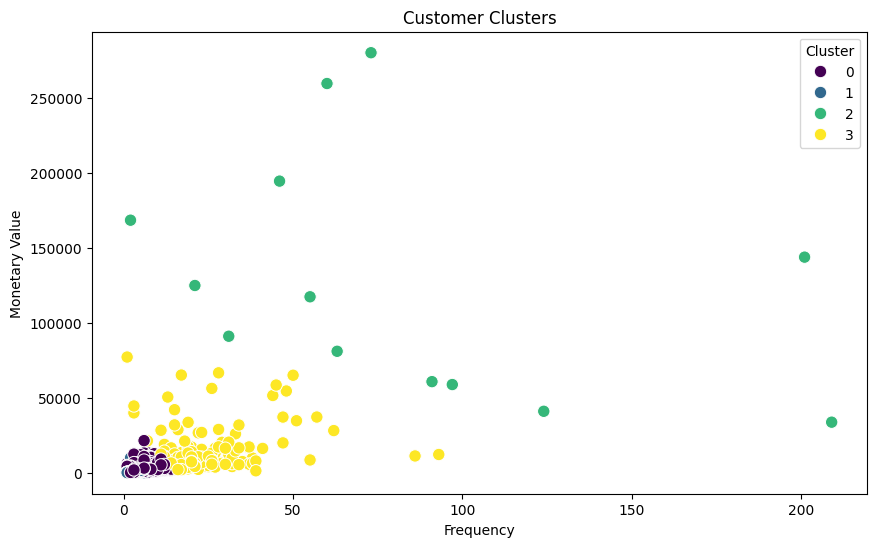

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Clusters')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')

plt.show()

In [40]:
rfm.to_csv(
    'Customer_Segmentation_Result.csv',
    index=False
)

print("File saved successfully!")

File saved successfully!
